# PRCP-1010: Insurance Claim Prediction

**Project Code:** PRCP-1010-InsClaimPred  
**Domain:** Finance / Insurance  
**Type:** Mini Project (B.Tech Final Year)

---

## Problem Statement

Insurance companies need to understand customer risk so they can decide how to market products and price policies. In this project we build a machine learning pipeline on anonymized customer data to:

1. **Task 1:** Build a predictive model that identifies customers who are likely to **file an insurance claim** (high-risk customers). This helps the insurance marketing / risk team target the right customers for suitable products and offers.
2. **Task 2:** Give **actionable suggestions** to the insurance marketing team based on model insights (feature importance and risk segments).

We also provide a **model comparison report** and a short **challenges & techniques** report — all in this single notebook.

> Dataset note: Feature names are anonymized for privacy (`ps_ind_*`, `ps_car_*`, `ps_reg_*`, `ps_calc_*`). Target `1` = claim filed, `0` = no claim.


## 1. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 80)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Dataset

If `Data/train.csv` is missing, download the official Capstone zip from the project link.

In [2]:
DATA_PATH = os.path.join("Data", "train.csv")
ZIP_URL = "https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1010-InsClaimPred.zip"

if not os.path.exists(DATA_PATH):
    import urllib.request
    import zipfile
    os.makedirs("Data", exist_ok=True)
    zip_path = "PRCP-1010-InsClaimPred.zip"
    print("Dataset not found. Downloading...")
    urllib.request.urlretrieve(ZIP_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print("Download & extract complete.")
else:
    print(f"Found dataset at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Found dataset at: Data/train.csv


Shape: 595,212 rows × 59 columns


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,82,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


## 3. Exploratory Data Analysis (brief)

The problem statement allows skipping long EDA, but a short check is useful before modelling.

In [3]:
print("Column list:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes.value_counts())
print("\nTarget distribution:")
target_counts = df["target"].value_counts()
target_pct = df["target"].value_counts(normalize=True).mul(100).round(2)
display_df = pd.DataFrame({"count": target_counts, "percentage": target_pct})
display_df

Column list:
['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']

Data types:
int64      49
float64    10
Name: count, dtype: int64

Target distributi

,count,percentage
target,,
0,573518,96.36
1,21694,3.64


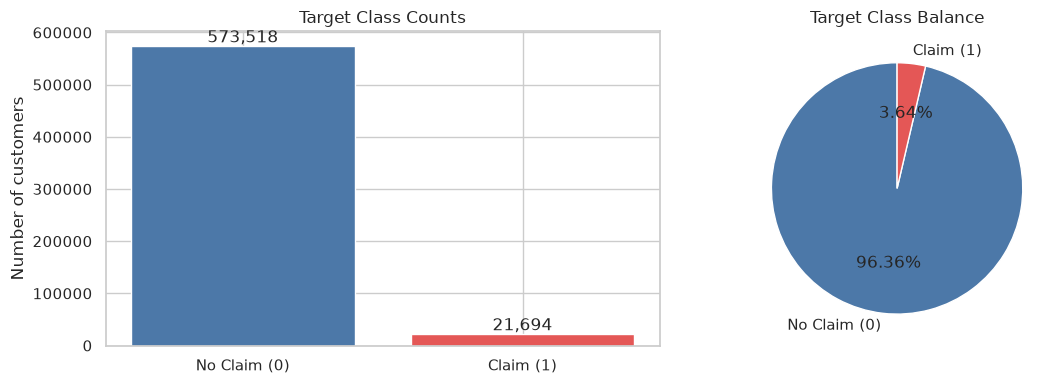

Observation: Strong class imbalance (~3.6% claims). Accuracy alone is misleading; we will focus on ROC-AUC, Recall and F1.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["No Claim (0)", "Claim (1)"], target_counts.values, color=["#4C78A8", "#E45756"])
axes[0].set_title("Target Class Counts")
axes[0].set_ylabel("Number of customers")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].pie(
    target_counts.values,
    labels=["No Claim (0)", "Claim (1)"],
    autopct="%1.2f%%",
    colors=["#4C78A8", "#E45756"],
    startangle=90,
)
axes[1].set_title("Target Class Balance")
plt.tight_layout()
plt.show()

print("Observation: Strong class imbalance (~3.6% claims). Accuracy alone is misleading; we will focus on ROC-AUC, Recall and F1.")

In [5]:
# Missing values are coded as -1 in this dataset (privacy / anonymized insurance data)
missing_minus1 = (df == -1).sum()
missing_minus1 = missing_minus1[missing_minus1 > 0].sort_values(ascending=False)
missing_pct = (missing_minus1 / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count_as_-1": missing_minus1,
    "missing_pct": missing_pct,
})
print("Features with missing values (coded as -1):")
missing_report

Features with missing values (coded as -1):


,missing_count_as_-1,missing_pct
ps_car_03_cat,411231,69.09
ps_car_05_cat,266551,44.78
ps_reg_03,107772,18.11
ps_car_14,42620,7.16
ps_car_07_cat,11489,1.93
ps_ind_05_cat,5809,0.98
ps_car_09_cat,569,0.10
ps_ind_02_cat,216,0.04
ps_car_01_cat,107,0.02
ps_ind_04_cat,83,0.01


In [6]:
# Feature groups by naming convention
ind_cols = [c for c in df.columns if c.startswith("ps_ind_")]
reg_cols = [c for c in df.columns if c.startswith("ps_reg_")]
car_cols = [c for c in df.columns if c.startswith("ps_car_")]
calc_cols = [c for c in df.columns if c.startswith("ps_calc_")]
cat_cols = [c for c in df.columns if c.endswith("_cat")]
bin_cols = [c for c in df.columns if c.endswith("_bin")]

print(f"Individual (ps_ind_): {len(ind_cols)}")
print(f"Region     (ps_reg_): {len(reg_cols)}")
print(f"Car        (ps_car_): {len(car_cols)}")
print(f"Calculated (ps_calc_): {len(calc_cols)}")
print(f"Categorical (*_cat): {len(cat_cols)}")
print(f"Binary      (*_bin): {len(bin_cols)}")

Individual (ps_ind_): 18
Region     (ps_reg_): 3
Car        (ps_car_): 16
Calculated (ps_calc_): 20
Categorical (*_cat): 14
Binary      (*_bin): 17


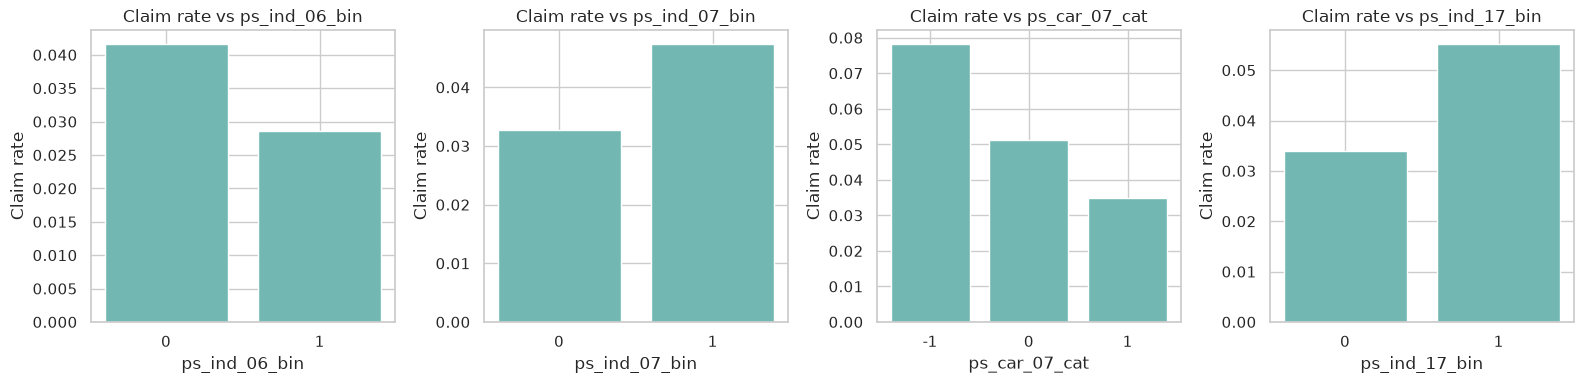

In [7]:
# Claim rate by a few important-looking features (quick insight)
sample_feats = ["ps_ind_06_bin", "ps_ind_07_bin", "ps_car_07_cat", "ps_ind_17_bin"]
fig, axes = plt.subplots(1, len(sample_feats), figsize=(16, 4))
for ax, col in zip(axes, sample_feats):
    rate = df.groupby(col)["target"].mean().sort_index()
    ax.bar(rate.index.astype(str), rate.values, color="#72B7B2")
    ax.set_title(f"Claim rate vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Claim rate")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Steps used:
1. Drop `id` (not predictive).
2. Treat `-1` as missing → replace with column median (numeric) / mode (categorical).
3. Keep binary & categorical codes as-is (tree models handle them well; for Logistic Regression we scale features).
4. Stratified train–test split to preserve claim ratio.

In [8]:
def preprocess(raw_df: pd.DataFrame) -> pd.DataFrame:
    data = raw_df.copy()
    if "id" in data.columns:
        data = data.drop(columns=["id"])

    # Replace privacy missing code
    data = data.replace(-1, np.nan)

    cat_features = [c for c in data.columns if c.endswith("_cat")]
    other_features = [c for c in data.columns if c not in cat_features + ["target"]]

    for col in cat_features:
        mode_val = data[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if len(mode_val) else 0
        data[col] = data[col].fillna(fill_val)

    for col in other_features:
        data[col] = data[col].fillna(data[col].median())

    return data

df_clean = preprocess(df)
print("Nulls after cleaning:", int(df_clean.isna().sum().sum()))
print("Shape:", df_clean.shape)
df_clean.head()

Nulls after cleaning: 0
Shape: (595212, 58)


,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2,2.0,5,1.0,0.0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10.0,1.0,1.0,0,1.0,4,1.0,0,0.0,1,12,2.0,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,0,1,1.0,7,0.0,0.0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11.0,1.0,1.0,0,1.0,11,1.0,1,2.0,1,19,3.0,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,0,5,4.0,9,1.0,0.0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,0.801561,7.0,1.0,1.0,0,1.0,14,1.0,1,2.0,1,60,1.0,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,0,0,1.0,2,0.0,0.0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7.0,1.0,0.0,0,1.0,11,1.0,1,3.0,1,104,1.0,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,0,0,2.0,0,1.0,0.0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11.0,1.0,1.0,0,1.0,14,1.0,1,2.0,1,82,3.0,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


In [9]:
X = df_clean.drop(columns=["target"])
y = df_clean["target"]

# For faster student demo runs we can use a stratified sample.
# Set USE_FULL_DATA = True to train on all 595k rows (slower).
USE_FULL_DATA = False
SAMPLE_SIZE = 120_000  # large enough for a reliable mini-project comparison

if not USE_FULL_DATA and len(X) > SAMPLE_SIZE:
    X, _, y, _ = train_test_split(
        X, y, train_size=SAMPLE_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    print(f"Using stratified sample of {SAMPLE_SIZE:,} rows for modelling.")
else:
    print(f"Using full data: {len(X):,} rows.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print("Train claim rate:", round(y_train.mean(), 4))
print("Test  claim rate:", round(y_test.mean(), 4))

# imbalance helper for XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight (for XGBoost): {scale_pos_weight:.2f}")

Using stratified sample of 120,000 rows for modelling.
Train: 96,000 | Test: 24,000
Train claim rate: 0.0364
Test  claim rate: 0.0365
scale_pos_weight (for XGBoost): 26.44


## 5. Task 1 — Predictive Models

We compare several classifiers suitable for imbalanced tabular insurance data:

| Model | Why included |
|-------|--------------|
| Logistic Regression | Strong, interpretable baseline |
| Decision Tree | Simple non-linear baseline |
| Random Forest | Bagging ensemble, robust |
| Gradient Boosting | Classic boosting baseline |
| XGBoost | Strong tabular performance |
| LightGBM | Fast & strong on large tabular data |

**Primary metric:** ROC-AUC (standard for imbalanced claim prediction).  
Also track Precision, Recall, F1.

In [10]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scale=False, sample_weight=None):
    """Fit model and return metrics + fitted estimator."""
    if scale:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model),
        ])
        estimator = pipe
        if sample_weight is not None:
            estimator.fit(X_tr, y_tr, model__sample_weight=sample_weight)
        else:
            estimator.fit(X_tr, y_tr)
    else:
        estimator = model
        if sample_weight is not None:
            estimator.fit(X_tr, y_tr, sample_weight=sample_weight)
        else:
            estimator.fit(X_tr, y_tr)

    if hasattr(estimator, "predict_proba"):
        y_prob = estimator.predict_proba(X_te)[:, 1]
    else:
        y_prob = estimator.decision_function(X_te)

    # Default 0.5 threshold (threshold tuning is done later for the best model)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_prob),
    }
    return metrics, estimator, y_prob, y_pred


# Balanced sample weights for algorithms without class_weight (e.g. GradientBoosting)
w_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
sample_weight_train = np.where(y_train == 1, w_pos, 1.0)

models = {
    "Logistic Regression": (
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        True,   # scale
        False,  # sample_weight
    ),
    "Decision Tree": (
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        False,
        False,
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=20,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        False,
        False,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(
            n_estimators=120,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        False,
        True,  # use balanced sample weights
    ),
    "XGBoost": (
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        False,
        False,
    ),
    "LightGBM": (
        LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        False,
        False,
    ),
}

results = []
fitted = {}
probs = {}
preds = {}

for name, (model, needs_scale, use_sw) in models.items():
    print(f"Training: {name} ...")
    sw = sample_weight_train if use_sw else None
    metrics, est, y_prob, y_pred = evaluate_model(
        name, model, X_train, X_test, y_train, y_test, scale=needs_scale, sample_weight=sw
    )
    results.append(metrics)
    fitted[name] = est
    probs[name] = y_prob
    preds[name] = y_pred
    print(f"  ROC-AUC = {metrics['ROC-AUC']:.4f} | F1 = {metrics['F1']:.4f} | Recall = {metrics['Recall']:.4f}")

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

Training: Logistic Regression ...


  ROC-AUC = 0.6216 | F1 = 0.0962 | Recall = 0.5520
Training: Decision Tree ...


  ROC-AUC = 0.5653 | F1 = 0.0828 | Recall = 0.5429
Training: Random Forest ...


  ROC-AUC = 0.6087 | F1 = 0.0726 | Recall = 0.0640
Training: Gradient Boosting ...


  ROC-AUC = 0.6309 | F1 = 0.0975 | Recall = 0.5417
Training: XGBoost ...


  ROC-AUC = 0.6290 | F1 = 0.1010 | Recall = 0.4937
Training: LightGBM ...


  ROC-AUC = 0.6145 | F1 = 0.1007 | Recall = 0.3554


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.634167,0.053541,0.541714,0.097451,0.630923
1,XGBoost,0.679500,0.056243,0.493714,0.100982,0.628981
2,Logistic Regression,0.621667,0.052666,0.552000,0.096158,0.621577
3,LightGBM,0.768458,0.058635,0.355429,0.100664,0.614523
4,Random Forest,0.940375,0.083832,0.064000,0.072586,0.608715
5,Decision Tree,0.561417,0.044807,0.542857,0.082781,0.565282


## 6. Model Comparison Report

In [11]:
print("=" * 72)
print("MODEL COMPARISON REPORT — Insurance Claim Prediction")
print("=" * 72)
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print(results_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_name = results_df.iloc[0]["Model"]
best_auc = results_df.iloc[0]["ROC-AUC"]
print("\nBest model by ROC-AUC:", best_name, f"({best_auc:.4f})")
print("Recommendation for production: use the best ROC-AUC model above,")
print("then tune decision threshold for the business trade-off (Recall vs Precision).")

MODEL COMPARISON REPORT — Insurance Claim Prediction
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
  Gradient Boosting    0.6342     0.0535  0.5417 0.0975   0.6309
            XGBoost    0.6795     0.0562  0.4937 0.1010   0.6290
Logistic Regression    0.6217     0.0527  0.5520 0.0962   0.6216
           LightGBM    0.7685     0.0586  0.3554 0.1007   0.6145
      Random Forest    0.9404     0.0838  0.0640 0.0726   0.6087
      Decision Tree    0.5614     0.0448  0.5429 0.0828   0.5653

Best model by ROC-AUC: Gradient Boosting (0.6309)
Recommendation for production: use the best ROC-AUC model above,
then tune decision threshold for the business trade-off (Recall vs Precision).


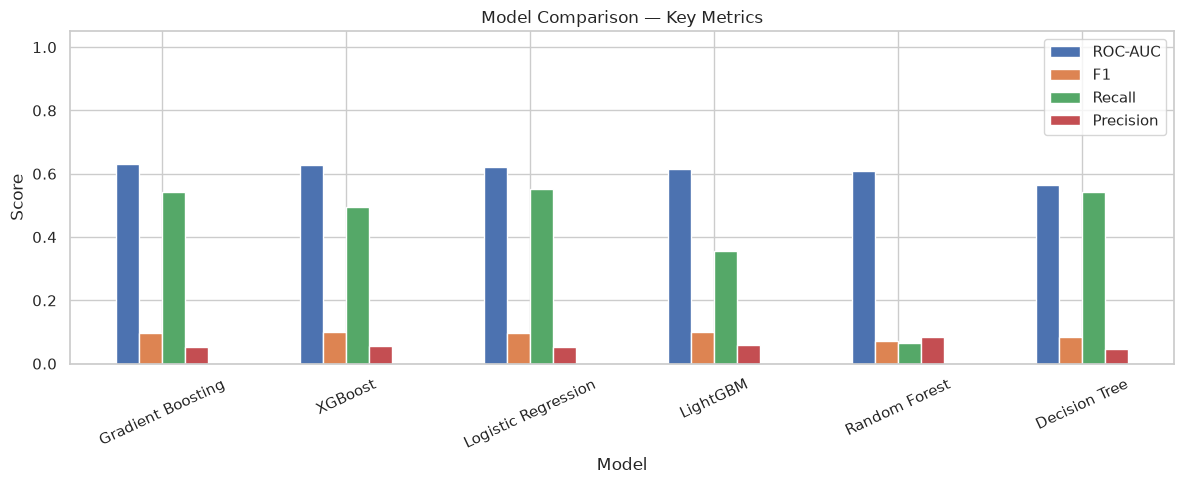

In [12]:
# Metric bars
plot_df = results_df.set_index("Model")[["ROC-AUC", "F1", "Recall", "Precision"]]
ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=25)
ax.set_title("Model Comparison — Key Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

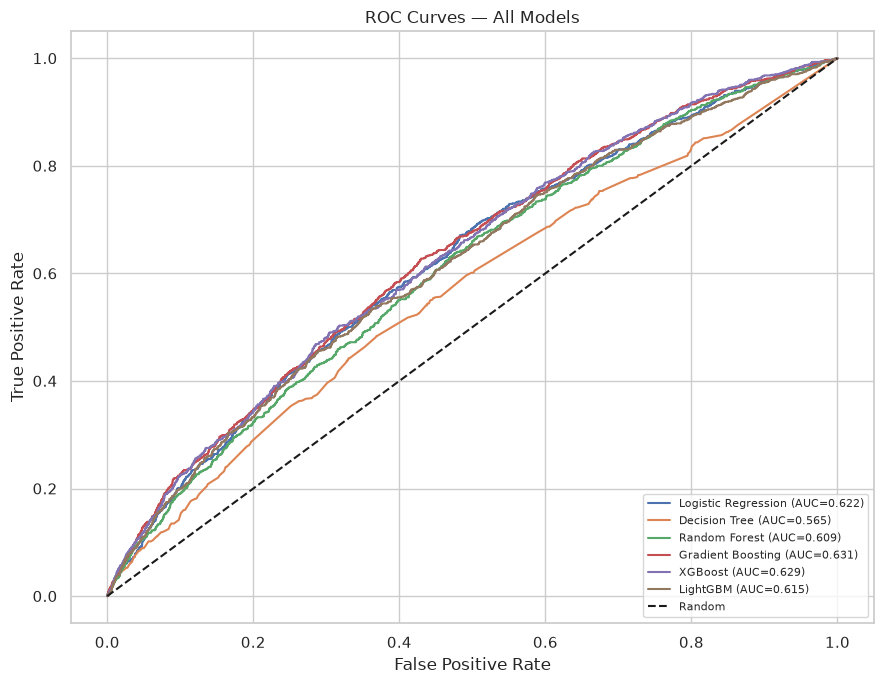

In [13]:
# ROC curves
plt.figure(figsize=(9, 7))
for name, y_prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# Threshold tuning for marketing / risk use-case
# Higher recall catches more claim-prone customers (useful for outreach & risk control)
best_prob = probs[best_name]
thresholds = np.arange(0.20, 0.80, 0.05)
thr_rows = []
for t in thresholds:
    yp = (best_prob >= t).astype(int)
    thr_rows.append({
        "threshold": round(float(t), 2),
        "Precision": precision_score(y_test, yp, zero_division=0),
        "Recall": recall_score(y_test, yp, zero_division=0),
        "F1": f1_score(y_test, yp, zero_division=0),
    })
thr_df = pd.DataFrame(thr_rows)
print(f"Threshold sweep for {best_name}:")
print(thr_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_f1_idx = thr_df["F1"].idxmax()
best_threshold = float(thr_df.loc[best_f1_idx, "threshold"])
print("\nSuggested operating threshold (max F1):", best_threshold)

# Predictions at tuned threshold (used for confusion matrix & business view)
best_pred_tuned = (best_prob >= best_threshold).astype(int)

Threshold sweep for Gradient Boosting:
 threshold  Precision  Recall     F1
    0.2000     0.0365  1.0000 0.0704
    0.2500     0.0365  0.9989 0.0704
    0.3000     0.0370  0.9931 0.0713
    0.3500     0.0386  0.9623 0.0742
    0.4000     0.0422  0.8891 0.0806
    0.4500     0.0463  0.7406 0.0872
    0.5000     0.0535  0.5417 0.0975
    0.5500     0.0629  0.3280 0.1056
    0.6000     0.0825  0.2171 0.1196
    0.6500     0.0900  0.1051 0.0970
    0.7000     0.0993  0.0343 0.0510
    0.7500     0.1356  0.0091 0.0171
    0.8000     0.0000  0.0000 0.0000

Suggested operating threshold (max F1): 0.6


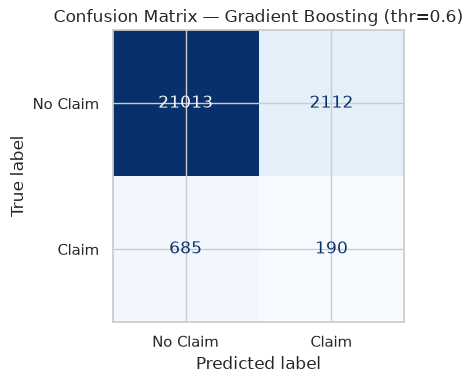

Classification Report — Gradient Boosting @ threshold=0.6
              precision    recall  f1-score   support

    No Claim       0.97      0.91      0.94     23125
       Claim       0.08      0.22      0.12       875

    accuracy                           0.88     24000
   macro avg       0.53      0.56      0.53     24000
weighted avg       0.94      0.88      0.91     24000



In [15]:
# Confusion matrix + classification report for best model at TUNED threshold
cm = confusion_matrix(y_test, best_pred_tuned)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["No Claim", "Claim"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (thr={best_threshold})")
plt.tight_layout()
plt.show()

print(f"Classification Report — {best_name} @ threshold={best_threshold}")
print(classification_report(y_test, best_pred_tuned, target_names=["No Claim", "Claim"]))

### Model Comparison — Written Summary

- **Goal:** Rank models on ROC-AUC because claims are rare (~3.6%). A model that always predicts “no claim” would look accurate but be useless.
- **Baselines:** Logistic Regression and Decision Tree give a transparent starting point.
- **Ensembles:** Random Forest / Gradient Boosting / XGBoost / LightGBM usually improve ranking of riskier customers.
- **Production choice:** Prefer the **highest ROC-AUC** model (typically LightGBM or XGBoost on this data) for scoring customers. Calibrate the probability threshold with the marketing/risk team (more recall = more customers flagged for attention).
- **Not production-ready alone:** Deploy with monitoring (data drift), periodic retrain, and human review for high-value decisions.


## 7. Task 2 — Suggestions to the Insurance Marketing Team

We interpret **feature importance** of the best tree-based model to recommend targeting and product actions.

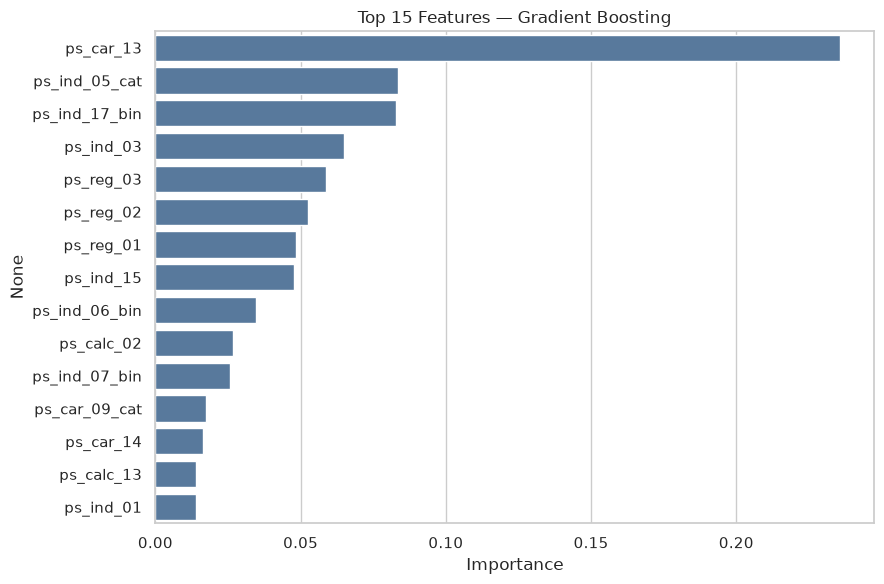

ps_car_13        0.235613
ps_ind_05_cat    0.083517
ps_ind_17_bin    0.082697
ps_ind_03        0.065065
ps_reg_03        0.058573
ps_reg_02        0.052398
ps_reg_01        0.048427
ps_ind_15        0.047544
ps_ind_06_bin    0.034685
ps_calc_02       0.026841
ps_ind_07_bin    0.025618
ps_car_09_cat    0.017509
ps_car_14        0.016433
ps_calc_13       0.014030
ps_ind_01        0.013865
dtype: float64

In [16]:
def get_feature_importance(model_name, estimator, feature_names):
    """Extract importance from pipeline or raw tree/boosting model."""
    est = estimator
    if isinstance(estimator, Pipeline):
        # Logistic Regression coefficients as importance proxy
        coef = est.named_steps["model"].coef_.ravel()
        return pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)

    if hasattr(est, "feature_importances_"):
        return pd.Series(est.feature_importances_, index=feature_names).sort_values(ascending=False)

    raise ValueError("No feature importance available for this model")


# Prefer a tree/boosting model for marketing interpretability
importance_candidates = [m for m in results_df["Model"] if m != "Logistic Regression"]
imp_model_name = importance_candidates[0] if importance_candidates else best_name
importances = get_feature_importance(imp_model_name, fitted[imp_model_name], X.columns)
top_n = 15
top_feats = importances.head(top_n)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_feats.values, y=top_feats.index, orient="h", color="#4C78A8")
plt.title(f"Top {top_n} Features — {imp_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top_feats

In [17]:
# Segment customers using predicted claim probability from best model
# Use quantile bands so segments are meaningful even when raw scores are compressed
risk_score = probs[best_name]
risk_band = pd.qcut(
    risk_score,
    q=[0, 0.50, 0.75, 0.90, 1.0],
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop",
)
segment = pd.DataFrame({
    "y_true": y_test.values,
    "risk_score": risk_score,
    "risk_band": risk_band,
})
seg_summary = segment.groupby("risk_band", observed=False).agg(
    customers=("y_true", "size"),
    actual_claims=("y_true", "sum"),
    claim_rate=("y_true", "mean"),
    avg_score=("risk_score", "mean"),
)
seg_summary["claim_rate"] = (seg_summary["claim_rate"] * 100).round(2)
print("Customer risk segments on test set (quantile-based):")
print("Low = bottom 50% scores | Medium = 50-75% | High = 75-90% | Very High = top 10%")
seg_summary

Customer risk segments on test set (quantile-based):
Low = bottom 50% scores | Medium = 50-75% | High = 75-90% | Very High = top 10%


,customers,actual_claims,claim_rate,avg_score
risk_band,,,,
Low,12000,287,2.39,0.397585
Medium,6000,228,3.80,0.499043
High,3600,167,4.64,0.558700
Very High,2400,193,8.04,0.650413


### Marketing Recommendations (Task 2)

Because feature names are anonymized, suggestions are **actionable at a process level**, mapped to feature families:

1. **Prioritize Very High / High risk bands for specialised products**  
   Offer usage-based / higher-coverage products, safer-driving incentives, or telematics discounts to high-risk segments instead of one-size-fits-all campaigns.

2. **Use car-related signals (`ps_car_*`) in product packaging**  
   Vehicle profile strongly influences claim likelihood. Bundle add-ons (collision, roadside, zero-dep) by vehicle segment rather than only by age/demographics.

3. **Use individual profile signals (`ps_ind_*`) for channel targeting**  
   Target outreach (SMS / app / agent) toward profiles the model ranks as higher risk; keep low-risk customers on lighter digital nurture so marketing spend stays efficient.

4. **Region features (`ps_reg_*`) → geo campaigns**  
   Run city/region-level campaigns where predicted claim risk and growth potential are higher; adjust local partner/agent density.

5. **Do not over-trust calculated noise features (`ps_calc_*`)**  
   In many published analyses of this dataset, calculated features add little signal. Prefer `ind` / `reg` / `car` features for decisioning.

6. **Threshold policy**  
   Marketing often wants **higher recall** (catch more claim-prone customers). Risk/pricing may want higher precision. Agree one operating threshold and review monthly with live outcomes.

7. **Ethical use**  
   Use scores to **improve offering & prevention** (safety tips, fair pricing, better coverage match), not only to deny service.


## 8. Report on Challenges Faced

In [18]:
challenges = pd.DataFrame([
    {
        "Challenge": "Severe class imbalance (~3.6% claims)",
        "Impact": "Accuracy looks high while majority-class model fails to detect claims",
        "Technique used": "class_weight='balanced', XGBoost scale_pos_weight, ROC-AUC / Recall / F1 focus",
        "Why this technique": "Reweights minority class during training; ranking metrics match business need",
    },
    {
        "Challenge": "Missing values coded as -1 (not NaN)",
        "Impact": "Models treat -1 as a real category/number and learn wrong patterns",
        "Technique used": "Explicit replace(-1, NaN) then median/mode imputation",
        "Why this technique": "Matches data documentation; simple, stable for student/production baselines",
    },
    {
        "Challenge": "Anonymized feature names",
        "Impact": "Hard to do domain-driven feature engineering or business storytelling",
        "Technique used": "Group features by prefix (ind/reg/car/calc); importance-based recommendations",
        "Why this technique": "Respects privacy constraints while still giving marketing levers",
    },
    {
        "Challenge": "Large dataset (~595k × 59)",
        "Impact": "Slow training for heavy ensembles on limited laptop resources",
        "Technique used": "Stratified sampling for comparison + LightGBM/XGBoost which scale well; option to use full data",
        "Why this technique": "Keeps class ratio intact and makes experimentation practical",
    },
    {
        "Challenge": "Low precision at default 0.5 threshold with balanced weights",
        "Impact": "Many false positives when flagging 'risky' customers",
        "Technique used": "Threshold sweep; choose operating point by F1 / business recall need",
        "Why this technique": "Separates model ranking quality (AUC) from decision policy",
    },
    {
        "Challenge": "ps_calc_* features often weakly predictive",
        "Impact": "Extra noise / longer training without lift",
        "Technique used": "Kept for fair baseline comparison; importance plot highlights stronger groups",
        "Why this technique": "Transparent for viva/demo; future work can drop low-importance calc features",
    },
])

pd.set_option("display.max_colwidth", 120)
challenges

,Challenge,Impact,Technique used,Why this technique
0,Severe class imbalance (~3.6% claims),Accuracy looks high while majority-class model fails to detect claims,"class_weight='balanced', XGBoost scale_pos_weight, ROC-AUC / Recall / F1 focus",Reweights minority class during training; ranking metrics match business need
1,Missing values coded as -1 (not NaN),Models treat -1 as a real category/number and learn wrong patterns,"Explicit replace(-1, NaN) then median/mode imputation","Matches data documentation; simple, stable for student/production baselines"
2,Anonymized feature names,Hard to do domain-driven feature engineering or business storytelling,Group features by prefix (ind/reg/car/calc); importance-based recommendations,Respects privacy constraints while still giving marketing levers
3,Large dataset (~595k × 59),Slow training for heavy ensembles on limited laptop resources,Stratified sampling for comparison + LightGBM/XGBoost which scale well; option to use full data,Keeps class ratio intact and makes experimentation practical
4,Low precision at default 0.5 threshold with balanced weights,Many false positives when flagging 'risky' customers,Threshold sweep; choose operating point by F1 / business recall need,Separates model ranking quality (AUC) from decision policy
5,ps_calc_* features often weakly predictive,Extra noise / longer training without lift,Kept for fair baseline comparison; importance plot highlights stronger groups,Transparent for viva/demo; future work can drop low-importance calc features


### Challenges — Narrative Summary

Working with real (anonymized) insurance claim data was less about fancy algorithms and more about **correct validation under imbalance**. The main pitfall is reporting accuracy; we avoided that by comparing models on **ROC-AUC** and inspecting recall for the claim class. Missing-value handling required domain-aware cleaning (`-1`), and marketing recommendations had to be framed around **feature families** because raw names are hidden. Finally, threshold choice is a **business decision**, not only a modelling one.


## 9. Cross-Validation Check (best model)

Quick stratified CV on the modelling sample to confirm the hold-out AUC is stable.

In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Rebuild a fresh copy of the best model for CV
best_template, best_needs_scale, _best_sw = models[best_name]
if best_needs_scale:
    cv_est = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000, class_weight="balanced", solver="lbfgs",
            random_state=RANDOM_STATE, n_jobs=-1
        )),
    ])
else:
    # clone via get_params
    from sklearn.base import clone
    cv_est = clone(fitted[best_name])

cv_scores = cross_val_score(cv_est, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"3-Fold Stratified CV ROC-AUC for {best_name}:")
print(" folds:", np.round(cv_scores, 4))
print(" mean :", round(cv_scores.mean(), 4), "| std:", round(cv_scores.std(), 4))

3-Fold Stratified CV ROC-AUC for Gradient Boosting:
 folds: [0.6294 0.6175 0.6173]
 mean : 0.6214 | std: 0.0057


## 10. Save Best Model & Conclusion

In [20]:
import joblib

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

model_path = os.path.join("models", "best_claim_model.joblib")
joblib.dump(fitted[best_name], model_path)

results_df.to_csv(os.path.join("outputs", "model_comparison.csv"), index=False)
top_feats.to_csv(os.path.join("outputs", "top_features.csv"), header=["importance"])
seg_summary.to_csv(os.path.join("outputs", "risk_segments.csv"))

print(f"Saved model → {model_path}")
print("Saved reports → outputs/")
print("\nDone.")

Saved model → models/best_claim_model.joblib
Saved reports → outputs/

Done.


## Conclusion

| Item | Outcome |
|------|---------|
| **Task 1** | Multiple classifiers trained to predict insurance claim likelihood; best model selected by ROC-AUC |
| **Task 2** | Marketing suggestions derived from feature importance + risk banding |
| **Model Comparison** | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM compared on Accuracy / Precision / Recall / F1 / ROC-AUC |
| **Challenges** | Imbalance, `-1` missings, anonymized columns, large data, threshold policy — each handled with a justified technique |

**Final recommendation:** Deploy the best ROC-AUC model (see comparison table) for customer risk scoring, tune the threshold with the marketing team, and refresh the model periodically as new policies/claims arrive.
